##### ARTI 560 - Computer Vision

## Action Recognition - Exercise

### Objective

In this exercise, you will train a deep learning model to recognize three specific human actions using the [UCF11 (YouTube Action) dataset](https://www.crcv.ucf.edu/data/UCF_YouTube_Action.php) and validate the model's real-world performance using external video data.

*[Note: This notebook is based on [this](https://github.com/Sumaya2026/learnopencv/tree/master/Optical-Flow-Estimation-using-Deep-Learning-RAFT) GitHub Repository by LearnOpenCV]*


#### Tasks

- Choose **three classes** from the UCF11 dataset (e.g., Basketball Shooting, Biking, Tennis Swinging, etc.).
- Preprocess the dataset.
- Split the data into training and testing.
- Create and train the model.
- Save the trained model .
    **Important Note**: The final trained model must be saved with a filename that includes your name. This is a mandatory step for the submission.
    ```
    # Example Code
    student_name = "YourName" # Replace with your actual name
    save_path = f"{student_name}_ucf11_model.h5"
    model.save(save_path)
    print(f"Model saved as {save_path}")
    ```
- Validate the model on 3 Youtube videos, each clearly showing one of your three chosen action classes.


In [1]:
import os
import zipfile

zip_path = r"C:\Users\Norah\OneDrive\GitHub\arti560-computer-vision-labs\lab07-action-recognition\YouTube_DataSet_Annotated (1).zip"
extract_to = r"C:\Users\Norah\OneDrive\GitHub\arti560-computer-vision-labs\lab07-action-recognition"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

print("Done extracting.")
print(os.listdir(extract_to))


Done extracting.
['action_youtube_naudio', 'lab07-action-recognition-exercise.ipynb', 'lab07-action-recognition.ipynb', 'Norah_Aldossary_ucf11_model___Date_Time_2026_05_03__15_05_11___Loss_0.2648710608482361___Accuracy_0.8916666507720947.h5', 'YouTube_DataSet_Annotated (1).zip', 'YouTube_videos']


In [2]:
import os
import cv2
import math
import random
import numpy as np
import datetime as dt
import tensorflow as tf
from collections import deque
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import train_test_split

from tensorflow.keras.layers import *
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import plot_model

In [3]:
seed_constant = 23
np.random.seed(seed_constant)
random.seed(seed_constant)
tf.random.set_seed(seed_constant)

In [4]:
dataset_directory = r"C:\Users\Norah\OneDrive\GitHub\arti560-computer-vision-labs\lab07-action-recognition\action_youtube_naudio"

print("Exists:", os.path.exists(dataset_directory))
print("Classes:", os.listdir(dataset_directory))


Exists: True
Classes: ['basketball', 'biking', 'diving', 'golf_swing', 'horse_riding', 'readme.txt', 'soccer_juggling', 'swing', 'tennis_swing', 'trampoline_jumping', 'volleyball_spiking', 'walking']


In [5]:
import os

dataset_directory = r"C:\Users\Norah\OneDrive\GitHub\arti560-computer-vision-labs\lab07-action-recognition\action_youtube_naudio"

all_classes_names = sorted(
    [d for d in os.listdir(dataset_directory) if os.path.isdir(os.path.join(dataset_directory, d))]
)

print(all_classes_names)


['basketball', 'biking', 'diving', 'golf_swing', 'horse_riding', 'soccer_juggling', 'swing', 'tennis_swing', 'trampoline_jumping', 'volleyball_spiking', 'walking']


In [6]:
selected_classes = ["basketball", "biking", "tennis_swing"]
print(selected_classes)


['basketball', 'biking', 'tennis_swing']


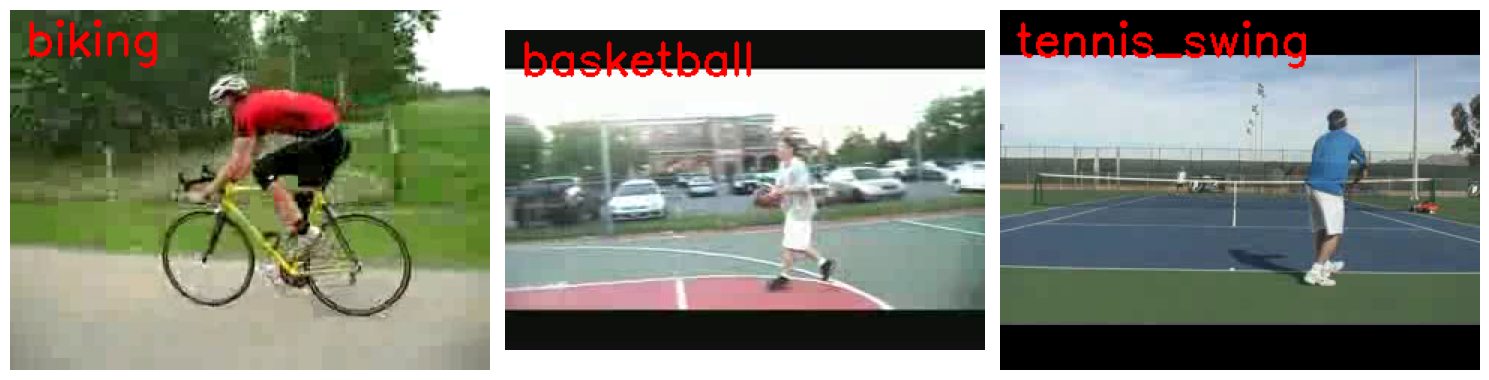

In [7]:
import os
import cv2
import random
import matplotlib.pyplot as plt

dataset_directory = r"C:\Users\Norah\OneDrive\GitHub\arti560-computer-vision-labs\lab07-action-recognition\action_youtube_naudio"

plt.figure(figsize=(15, 8))

all_classes_names = selected_classes
random_range = random.sample(range(len(all_classes_names)), len(all_classes_names))

for counter, random_index in enumerate(random_range, 1):
    selected_class_Name = all_classes_names[random_index]
    class_path = os.path.join(dataset_directory, selected_class_Name)

    video_files_names_list = []
    for root, _, files in os.walk(class_path):
        for f in files:
            if f.lower().endswith((".avi", ".mp4", ".mov", ".mkv")):
                video_files_names_list.append(os.path.join(root, f))

    if not video_files_names_list:
        print(f"No video files found in {selected_class_Name}")
        continue

    video_path = random.choice(video_files_names_list)

    video_reader = cv2.VideoCapture(video_path)
    success, bgr_frame = video_reader.read()
    video_reader.release()

    if not success:
        print(f"Could not read video: {video_path}")
        continue

    rgb_frame = cv2.cvtColor(bgr_frame, cv2.COLOR_BGR2RGB)
    cv2.putText(rgb_frame, selected_class_Name, (10, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 2)

    plt.subplot(1, len(all_classes_names), counter)
    plt.imshow(rgb_frame)
    plt.axis('off')

plt.tight_layout()
plt.show()


In [8]:
image_height, image_width = 64, 64
max_images_per_class = 1000

dataset_directory = r"C:\Users\Norah\OneDrive\GitHub\arti560-computer-vision-labs\lab07-action-recognition\action_youtube_naudio"
classes_list = selected_classes

model_output_size = len(classes_list)
print("Image Size:", (image_height, image_width))

Image Size: (64, 64)


In [9]:
def frames_extraction(video_path):
    # Empty List declared to store video frames
    frames_list = []
    
    # Reading the Video File Using the VideoCapture
    video_reader = cv2.VideoCapture(video_path)

    # Iterating through Video Frames
    while True:

        # Reading a frame from the video file 
        success, frame = video_reader.read() 

        # If Video frame was not successfully read then break the loop
        if not success:
            break

        # Resize the Frame to fixed Dimensions
        resized_frame = cv2.resize(frame, (image_height, image_width))
        
        # Normalize the resized frame by dividing it with 255 so that each pixel value then lies between 0 and 1
        normalized_frame = resized_frame / 255
        
        # Appending the normalized frame into the frames list
        frames_list.append(normalized_frame)
    
    # Closing the VideoCapture object and releasing all resources. 
    video_reader.release()

    # returning the frames list 
    return frames_list

In [10]:
def create_dataset():
    features = []
    labels = []

    for class_index, class_name in enumerate(classes_list):
        print(f'Extracting Data of Class: {class_name}')
        temp_features = []

        class_path = os.path.join(dataset_directory, class_name)

        # Walk through nested folders in UCF11
        for root, _, files in os.walk(class_path):
            for file_name in files:
                if file_name.lower().endswith((".avi", ".mp4", ".mov", ".mkv")):
                    video_file_path = os.path.join(root, file_name)

                    frames = frames_extraction(video_file_path)
                    temp_features.extend(frames)

        print(f"Total extracted frames for {class_name}: {len(temp_features)}")

        if len(temp_features) == 0:
            print(f"Skipping {class_name} because no frames were found.")
            continue

        sample_count = min(max_images_per_class, len(temp_features))

        features.extend(random.sample(temp_features, sample_count))
        labels.extend([class_index] * sample_count)

    features = np.asarray(features)
    labels = np.array(labels)

    return features, labels


In [11]:
features, labels = create_dataset()

Extracting Data of Class: basketball
Total extracted frames for basketball: 15092
Extracting Data of Class: biking
Total extracted frames for biking: 25272
Extracting Data of Class: tennis_swing
Total extracted frames for tennis_swing: 24096


In [12]:
# Using Keras's to_categorical method to convert labels into one-hot-encoded vectors
one_hot_encoded_labels = to_categorical(labels)

In [13]:
features_train, features_test, labels_train, labels_test = train_test_split(features, one_hot_encoded_labels, test_size = 0.2, shuffle = True, random_state = seed_constant)

In [14]:
# Let's create a function that will construct our model
def create_model():

    # We will use a Sequential model for model construction
    model = Sequential()

    # Defining The Model Architecture
    model.add(Conv2D(filters = 64, kernel_size = (3, 3), activation = 'relu', input_shape = (image_height, image_width, 3)))
    model.add(Conv2D(filters = 64, kernel_size = (3, 3), activation = 'relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size = (2, 2)))
    model.add(GlobalAveragePooling2D())
    model.add(Dense(256, activation = 'relu'))
    model.add(BatchNormalization())
    model.add(Dense(model_output_size, activation = 'softmax'))

    # Printing the models summary
    model.summary()

    return model


# Calling the create_model method
model = create_model()

print("Model Created Successfully!")

d:\Norah\Anaconda\mAnaconda\envs\video-classification\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 60, 60, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 60, 60, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 57,411 (224.26 KB)

 Trainable params: 56,771 (221.76 KB)

 Non-trainable params: 640 (2.50 KB)

Model Created Successfully!


In [15]:
plot_model(model, to_file = 'model_structure_plot.png', show_shapes = True, show_layer_names = True)

You must install pydot (`pip install pydot`) for `plot_model` to work.


In [17]:
# Adding the Early Stopping Callback to the model which will continuously monitor the validation loss metric for every epoch.
# If the models validation loss does not decrease after 15 consecutive epochs, the training will be stopped and the weight which reported the lowest validation loss will be retored in the model.
early_stopping_callback = EarlyStopping(monitor = 'val_loss', patience = 15, mode = 'min', restore_best_weights = True)

# Adding loss, optimizer and metrics values to the model.
model.compile(loss = 'categorical_crossentropy', optimizer = 'Adam', metrics = ["accuracy"])

# Start Training
model_training_history = model.fit(x = features_train, y = labels_train, epochs = 50, batch_size = 10 , shuffle = True, validation_split = 0.2, callbacks = [early_stopping_callback])

Epoch 1/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 25s 120ms/step - accuracy: 0.6208 - loss: 0.8437 - val_accuracy: 0.3604 - val_loss: 1.0866
Epoch 2/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 22s 116ms/step - accuracy: 0.7604 - loss: 0.5700 - val_accuracy: 0.6062 - val_loss: 0.8825
Epoch 3/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 22s 116ms/step - accuracy: 0.8109 - loss: 0.4648 - val_accuracy: 0.5042 - val_loss: 2.9186
Epoch 4/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 22s 116ms/step - accuracy: 0.8740 - loss: 0.3409 - val_accuracy: 0.6687 - val_loss: 0.9672
Epoch 5/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 23s 119ms/step - accuracy: 0.9057 - loss: 0.2695 - val_accuracy: 0.8042 - val_loss: 0.4698
Epoch 6/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 23s 122ms/step - accuracy: 0.9104 - loss: 0.2332 - val_accuracy: 0.7042 - val_loss: 0.7434
Epoch 7/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 23s 121ms/step - accuracy: 0.9266 - loss: 0.1917 - val_accuracy: 0.8896 - val_loss: 0.2821
Epoch 8/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 23s 118ms/step - accuracy: 0.9453 - loss: 0

In [18]:
model_evaluation_history = model.evaluate(features_test, labels_test)

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.9933 - loss: 0.0101


In [19]:
student_name = "Norah_Aldossary"

date_time_format = '%Y_%m_%d__%H_%M_%S'
current_date_time_dt = dt.datetime.now()
current_date_time_string = dt.datetime.strftime(current_date_time_dt, date_time_format)
model_evaluation_loss, model_evaluation_accuracy = model_evaluation_history
model_name = f'{student_name}_ucf11_model___Date_Time_{current_date_time_string}___Loss_{model_evaluation_loss}___Accuracy_{model_evaluation_accuracy}.h5'

model.save(model_name)
print(f"Model saved as {model_name}")

Model saved as Norah_Aldossary_ucf11_model___Date_Time_2026_05_04__14_51_35___Loss_0.010115445591509342___Accuracy_0.9933333396911621.h5


In [20]:
def plot_metric(metric_name_1, metric_name_2, plot_name):
  # Get Metric values using metric names as identifiers
  metric_value_1 = model_training_history.history[metric_name_1]
  metric_value_2 = model_training_history.history[metric_name_2]

  # Constructing a range object which will be used as time 
  epochs = range(len(metric_value_1))
  
  # Plotting the Graph
  plt.plot(epochs, metric_value_1, 'blue', label = metric_name_1)
  plt.plot(epochs, metric_value_2, 'red', label = metric_name_2)
  
  # Adding title to the plot
  plt.title(str(plot_name))

  # Adding legend to the plot
  plt.legend()

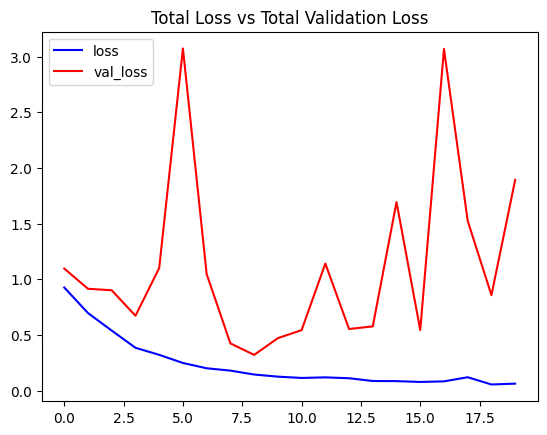

In [41]:
plot_metric('loss', 'val_loss', 'Total Loss vs Total Validation Loss')

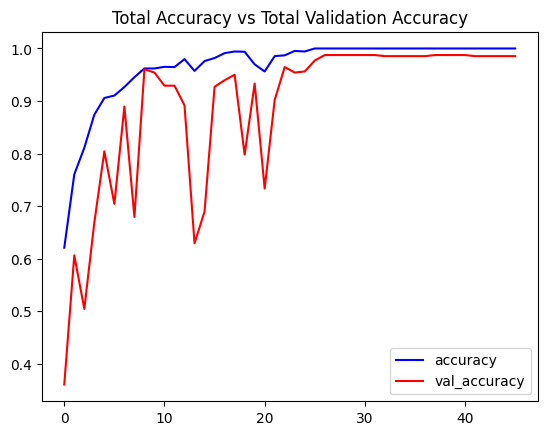

In [21]:
plot_metric('accuracy', 'val_accuracy', 'Total Accuracy vs Total Validation Accuracy')


In [22]:
def predict_on_live_video(video_file_path, output_file_path, window_size):

    predicted_labels_probabilities_deque = deque(maxlen = window_size)

    video_reader = cv2.VideoCapture(video_file_path)

    original_video_width = int(video_reader.get(cv2.CAP_PROP_FRAME_WIDTH))
    original_video_height = int(video_reader.get(cv2.CAP_PROP_FRAME_HEIGHT))

    video_writer = cv2.VideoWriter(output_file_path, cv2.VideoWriter_fourcc('M', 'P', '4', 'V'), 24, (original_video_width, original_video_height))

    while True:

        status, frame = video_reader.read()

        if not status:
            break

        resized_frame = cv2.resize(frame, (image_height, image_width))

        normalized_frame = resized_frame / 255

        predicted_labels_probabilities = model.predict(np.expand_dims(normalized_frame, axis = 0), verbose = 0)[0]

        predicted_labels_probabilities_deque.append(predicted_labels_probabilities)

        if len(predicted_labels_probabilities_deque) == window_size:

            predicted_labels_probabilities_np = np.array(predicted_labels_probabilities_deque)

            predicted_labels_probabilities_averaged = predicted_labels_probabilities_np.mean(axis = 0)

            predicted_label = np.argmax(predicted_labels_probabilities_averaged)

            predicted_class_name = classes_list[predicted_label]

            cv2.putText(frame, predicted_class_name, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)

        video_writer.write(frame)

    video_reader.release()
    video_writer.release()


In [23]:
def predict_on_live_video(video_file_path, output_file_path, window_size):

    # Initialize a Deque Object with a fixed size which will be used to implement moving/rolling average functionality.
    predicted_labels_probabilities_deque = deque(maxlen = window_size)

    # Reading the Video File using the VideoCapture Object
    video_reader = cv2.VideoCapture(video_file_path)

    # Getting the width and height of the video 
    original_video_width = int(video_reader.get(cv2.CAP_PROP_FRAME_WIDTH))
    original_video_height = int(video_reader.get(cv2.CAP_PROP_FRAME_HEIGHT))

    # Writing the Overlayed Video Files Using the VideoWriter Object
    video_writer = cv2.VideoWriter(output_file_path, cv2.VideoWriter_fourcc('M', 'P', '4', 'V'), 24, (original_video_width, original_video_height))

    while True: 

        # Reading The Frame
        status, frame = video_reader.read() 

        if not status:
            break

        # Resize the Frame to fixed Dimensions
        resized_frame = cv2.resize(frame, (image_height, image_width))
        
        # Normalize the resized frame by dividing it with 255 so that each pixel value then lies between 0 and 1
        normalized_frame = resized_frame / 255

        # Passing the Image Normalized Frame to the model and receiving Predicted Probabilities.
        predicted_labels_probabilities = model.predict(np.expand_dims(normalized_frame, axis = 0),verbose=0)[0]

        # Appending predicted label probabilities to the deque object
        predicted_labels_probabilities_deque.append(predicted_labels_probabilities)

        # Assuring that the Deque is completely filled before starting the averaging process
        if len(predicted_labels_probabilities_deque) == window_size:

            # Converting Predicted Labels Probabilities Deque into Numpy array
            predicted_labels_probabilities_np = np.array(predicted_labels_probabilities_deque)

            # Calculating Average of Predicted Labels Probabilities Column Wise 
            predicted_labels_probabilities_averaged = predicted_labels_probabilities_np.mean(axis = 0)

            # Converting the predicted probabilities into labels by returning the index of the maximum value.
            predicted_label = np.argmax(predicted_labels_probabilities_averaged)

            # Accessing The Class Name using predicted label.
            predicted_class_name = classes_list[predicted_label]
          
            # Overlaying Class Name Text Ontop of the Frame
            cv2.putText(frame, predicted_class_name, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)

        # Writing The Frame
        video_writer.write(frame)


        # cv2.imshow('Predicted Frames', frame)

        # key_pressed = cv2.waitKey(10)

        # if key_pressed == ord('q'):
        #     break

    # cv2.destroyAllWindows()

    
    # Closing the VideoCapture and VideoWriter objects and releasing all resources held by them. 
    video_reader.release()
    video_writer.release()

In [26]:
def get_existing_path(paths):
    for path in paths:
        if os.path.exists(path):
            return path
    return None

output_directory = r'C:\Users\Norah\OneDrive\GitHub\arti560-computer-vision-labs\lab07-action-recognition\YouTube_videos'
os.makedirs(output_directory, exist_ok = True)

def get_existing_path(paths):
    for path in paths:
        if os.path.exists(path):
            return path
    return None

output_directory = r'C:\Users\Norah\OneDrive\GitHub\arti560-computer-vision-labs\lab07-action-recognition\YouTube_videos'
os.makedirs(output_directory, exist_ok = True)

youtube_videos_urls = {
    'basketball': get_existing_path([
        r'C:\Users\Norah\OneDrive\GitHub\arti560-computer-vision-labs\lab07-action-recognition\YouTube_videos\basketball.mp4',
        r'C:\Users\Norah\OneDrive\GitHub\arti560-computer-vision-labs\lab07-action-recognition\YouTube_videos\basketball2.mp4',
        r'C:\Users\Norah\OneDrive\GitHub\arti560-computer-vision-labs\lab07-action-recognition\YouTube_videos\basketball3.mp4'
    ]),
    'biking': get_existing_path([
        r'C:\Users\Norah\OneDrive\GitHub\arti560-computer-vision-labs\lab07-action-recognition\YouTube_videos\biking.mp4',
        r'C:\Users\Norah\OneDrive\GitHub\arti560-computer-vision-labs\lab07-action-recognition\YouTube_videos\biking2.mp4',
        r'C:\Users\Norah\OneDrive\GitHub\arti560-computer-vision-labs\lab07-action-recognition\YouTube_videos\biking3.mp4'
    ]),
    'tennis_swing': get_existing_path([
        r'C:\Users\Norah\OneDrive\GitHub\arti560-computer-vision-labs\lab07-action-recognition\YouTube_videos\tennis swing.mp4',
        r'C:\Users\Norah\OneDrive\GitHub\arti560-computer-vision-labs\lab07-action-recognition\YouTube_videos\tennis swing2.mp4',
        r'C:\Users\Norah\OneDrive\GitHub\arti560-computer-vision-labs\lab07-action-recognition\YouTube_videos\tennis swing3.mp4'
    ])
}


In [ ]:
# Setting sthe Widow Size which will be used by the Rolling Averge Proces
window_size = 1

# Construting The Output YouTube Video Path
for video_title, input_video_file_path in youtube_videos_urls.items():
    if input_video_file_path is None or input_video_file_path == '':
        print(f"Skipping {video_title} - video file not found")
        continue
    
    output_video_file_path = f'{output_directory}/{video_title} -Output-WSize {window_size}.mp4'
    
    predict_on_live_video(input_video_file_path, output_video_file_path, window_size)

# Calling the predict_on_live_video method to start the Prediction.
predict_on_live_video(input_video_file_path, output_video_file_path, window_size)

NameError: name 'video_title' is not defined

In [75]:
# Setting the Widow Size which will be used by the Rolling Averge Process
window_size = 25

# Construting The Output YouTube Video Path
output_video_file_path = f'{output_directory}/{video_title} -Output-WSize {window_size}.mp4'

# Calling the predict_on_live_video method to start the Prediction and Rolling Averge Process
predict_on_live_video(input_video_file_path, output_video_file_path, window_size)

In [76]:
def make_average_predictions(video_file_path, predictions_frames_count):
    
    # Initializing the Numpy array which will store Prediction Probabilities
    predicted_labels_probabilities_np = np.zeros((predictions_frames_count, model_output_size), dtype = float)

    # Reading the Video File using the VideoCapture Object
    video_reader = cv2.VideoCapture(video_file_path)

    # Getting The Total Frames present in the video 
    video_frames_count = int(video_reader.get(cv2.CAP_PROP_FRAME_COUNT))

    # Calculating The Number of Frames to skip Before reading a frame
    skip_frames_window = video_frames_count // predictions_frames_count

    for frame_counter in range(predictions_frames_count): 

        # Setting Frame Position
        video_reader.set(cv2.CAP_PROP_POS_FRAMES, frame_counter * skip_frames_window)

        # Reading The Frame
        _ , frame = video_reader.read() 

        # Resize the Frame to fixed Dimensions
        resized_frame = cv2.resize(frame, (image_height, image_width))
        
        # Normalize the resized frame by dividing it with 255 so that each pixel value then lies between 0 and 1
        normalized_frame = resized_frame / 255

        # Passing the Image Normalized Frame to the model and receiving Predicted Probabilities.
        predicted_labels_probabilities = model.predict(np.expand_dims(normalized_frame, axis = 0),verbose=0)[0]

        # Appending predicted label probabilities to the deque object
        predicted_labels_probabilities_np[frame_counter] = predicted_labels_probabilities

    # Calculating Average of Predicted Labels Probabilities Column Wise 
    predicted_labels_probabilities_averaged = predicted_labels_probabilities_np.mean(axis = 0)

    # Sorting the Averaged Predicted Labels Probabilities
    predicted_labels_probabilities_averaged_sorted_indexes = np.argsort(predicted_labels_probabilities_averaged)[::-1]

    # Iterating Over All Averaged Predicted Label Probabilities
    for predicted_label in predicted_labels_probabilities_averaged_sorted_indexes:

        # Accessing The Class Name using predicted label.
        predicted_class_name = classes_list[predicted_label]

        # Accessing The Averaged Probability using predicted label.
        predicted_probability = predicted_labels_probabilities_averaged[predicted_label]

        print(f"CLASS NAME: {predicted_class_name:<15} AVERAGED PROBABILITY: {predicted_probability:.2f}")    

    # Closing the VideoCapture Object and releasing all resources held by it. 
    video_reader.release()

In [77]:
# Calling The Make Average Method To Start The Process
for video_title, input_video_file_path in youtube_videos_urls.items():
    if input_video_file_path is None or input_video_file_path == '':
        print(f"Skipping {video_title} - video file not found")
        continue
    
    print(f'Predictions for {video_title}:')
    make_average_predictions(input_video_file_path, 50)
    print()

Predictions for basketball:
CLASS NAME: tennis_swing    AVERAGED PROBABILITY: 0.54
CLASS NAME: basketball      AVERAGED PROBABILITY: 0.34
CLASS NAME: biking          AVERAGED PROBABILITY: 0.12

Predictions for biking:
CLASS NAME: basketball      AVERAGED PROBABILITY: 0.72
CLASS NAME: tennis_swing    AVERAGED PROBABILITY: 0.22
CLASS NAME: biking          AVERAGED PROBABILITY: 0.06

Predictions for tennis_swing:
CLASS NAME: basketball      AVERAGED PROBABILITY: 0.97
CLASS NAME: biking          AVERAGED PROBABILITY: 0.02
CLASS NAME: tennis_swing    AVERAGED PROBABILITY: 0.01

